# Finding rate RNN fixed points

- condensing the code and finding fixed points for other time points too during delay
- include both good and bad models

In [1]:
import os, scipy.io 
import numpy as np 
# %matplotlib ipympl
import matplotlib.pyplot as plt 
from mpl_toolkits.mplot3d import axes3d
import sys
import pickle as pk
from sklearn.decomposition import PCA

sys.path.append('/home/nuttidalab/Documents/spikeRNN/rate/')
# import model
from model import generate_input_stim_xor, eval_tf

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/')
import vis_utils as vu
import trajectory_utils as tu
import importlib

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/trajectory/fixed_pt/')
import load_RNN_model as lrm

sys.path.append('/home/nuttidalab/Documents/spikeRNN/analysis_code/utils/fixed-point-finder')
from FixedPointFinderTorch import FixedPointFinderTorch as FixedPointFinder
from plot_utils import plot_fps # in fixedpointfinder folder

2025-03-01 18:14:58.920790: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-03-01 18:14:58.929429: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-01 18:14:58.938075: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-01 18:14:58.940691: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-01 18:14:58.947970: I tensorflow/core/platform/cpu_feature_guar

Instructions for updating:
non-resource variables are not supported in the long term


/home/nuttidalab/anaconda3/envs/rnn_test/lib/python3.11/site-packages/torch/utils/_pytree.py:185: FutureWarning: optree is installed but the version is too old to support PyTorch Dynamo in C++ pytree. C++ pytree support is disabled. Please consider upgrading optree using `python3 -m pip install --upgrade 'optree>=0.13.0'`.
  warnings.warn(


## Good model

In [2]:
models_type = 'good_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [3]:
RNN_model_file = model_list[0] # just grab the first model
model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'

print(f'Loading model: {RNN_model_file}')
rnn_path = os.path.join(models_dir, RNN_model_file) 
model = lrm.load_RNN_model(rnn_path)

settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 50, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

xx_trials = np.load(f'{model_results_dir}synX.npy')
trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels.npy')

stim_on = settings['stim_on']
stim_dur = settings['stim_dur']
delay=settings['delay']
T = settings['T']

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659.mat


In [ ]:
# run if it's the first time for this model
fixed_pt_results = {}

task_types = [1, -1] # for the first stimulus
time_fp_labels = ['start','middle','end'] # relative to the delay period
n_initial = 200

fpf_hps = {
			'max_iters': 30000,
			'lr_init': 0.1,
			'outlier_distance_scale': 10.0,			
			'tol_unique':10, #75
			'verbose': True, 
			'super_verbose': True}

for task_type in task_types:
    for time_fp_label in time_fp_labels:
        print(f'Finding fixed points for task type {task_type} and {time_fp_label} of delay period')
        stim1_times = np.arange(stim_on,stim_on+stim_dur)
        delay_times = np.arange(stim_on+stim_dur,stim_on+stim_dur+delay)
        xx_trials_stim1 = xx_trials[trial_stim_labels[:,0] == task_type,:,:][:,stim1_times,:]
        xx_trials_delay = xx_trials[trial_stim_labels[:,0] == task_type,:,:][:,delay_times,:]

        initial_states = np.zeros((n_initial,xx_trials_delay.shape[2])) # n_initial x nNeurons
        for iI in np.arange(n_initial):
            rand_trial = np.random.randint(xx_trials_delay.shape[0])
            if time_fp_label == 'start':
                initial_states[iI,:] = xx_trials_stim1[rand_trial,-1,:] # last time point of the stimulus
            elif time_fp_label == 'middle':
                mid_delay = int((delay_times[-1] - delay_times[0])/2)
                initial_states[iI,:] = xx_trials_delay[rand_trial,mid_delay,:] # middle of delay period
            elif time_fp_label == 'end':
                initial_states[iI,:] = xx_trials_delay[rand_trial,-2,:] # end of delay period
        
        # Choosing input vector u for each trial type/modality type
        inputs = np.zeros((1, 2))
        inputs[0, 0] = 0 # no stim for maintenance period

        # Defining and running fixed point optimization
        fpf = FixedPointFinder(model, **fpf_hps)
        unique_fps,all_fps = fpf.find_fixed_points(initial_states, inputs)    
        fp_dict = {'xstar': unique_fps.xstar, 'is_stable':unique_fps.is_stable, \
                'J_xstar':unique_fps.J_xstar, 'eigval_J_xstar': unique_fps.eigval_J_xstar, \
                    'eigvec_J_xstar':unique_fps.eigvec_J_xstar}
        fixed_pt_results[(task_type, time_fp_label)] = {
            'xstar': unique_fps.xstar,
            'is_stable': unique_fps.is_stable,
            'J_xstar': unique_fps.J_xstar,
            'eigval_J_xstar': unique_fps.eigval_J_xstar,
            'eigvec_J_xstar': unique_fps.eigvec_J_xstar
        }

Finding fixed points for task type 1 and start of delay period

Searching for fixed points from 200 initial states.

	Freezing model parameters so model is not affected by fixed point optimization.
	Finding fixed points via joint optimization.
	Iter: 100, q = 1.59e-02 +/- 2.73e-03, dq = 1.13e-04 +/- 1.53e-05, learning rate = 1.00e-01, avg iter time = 1.10e-03 sec.
	Iter: 200, q = 8.70e-03 +/- 1.92e-03, dq = 5.17e-05 +/- 1.14e-05, learning rate = 1.00e-01, avg iter time = 1.01e-03 sec.
	Iter: 300, q = 4.79e-03 +/- 1.29e-03, dq = 4.48e-05 +/- 7.92e-05, learning rate = 1.00e-01, avg iter time = 9.86e-04 sec.
	Iter: 400, q = 2.54e-03 +/- 7.52e-04, dq = 3.84e-05 +/- 9.64e-05, learning rate = 9.50e-02, avg iter time = 9.71e-04 sec.
	Iter: 500, q = 1.41e-03 +/- 4.25e-04, dq = 1.77e-05 +/- 4.93e-05, learning rate = 9.02e-02, avg iter time = 9.61e-04 sec.
	Iter: 600, q = 8.30e-04 +/- 2.38e-04, dq = 4.60e-06 +/- 4.94e-06, learning rate = 8.15e-02, avg iter time = 9.55e-04 sec.
	Iter: 700, q = 5.

In [ ]:
# import pickle as pk

# pk.dump(fixed_pt_results, open(f'{model_results_dir}fixed_pt_results.pkl', 'wb'))

In [4]:
# load pickle
fixed_pt_results = pk.load(open(f'{model_results_dir}fixed_pt_results.pkl', 'rb'))

#### now PCA

In [5]:
task_types = [1, -1] # for the first stimulus
time_fp_labels = ['start','middle','end'] # relative to the delay period

In [6]:
# concatenate trials in time dimension to get a neurons x time matrix

xx_trials_thrudelay = xx_trials[:,:stim_on+stim_dur+delay,:] # nTrials x nTimes x nNeurons

n_neurons = xx_trials_thrudelay.shape[2]
n_times = xx_trials_thrudelay.shape[1]

xx_concatenated = xx_trials_thrudelay.reshape(-1,n_neurons)
n_xx = xx_concatenated.shape[0]

# concatenate the fixed points to the trials
for task_type in task_types:
    for time_fp_label in time_fp_labels:
        fp_dict = fixed_pt_results[(task_type, time_fp_label)]
        xx_concatenated = np.concatenate((xx_concatenated, fp_dict['xstar']),axis=0)

n_fixed_pts = xx_concatenated.shape[0] - n_xx
print(n_fixed_pts)
print(xx_concatenated.shape)


14
(300014, 200)


In [7]:
# do pca
pca = PCA(n_components=3)
pca.fit(xx_concatenated)
xx_pca = pca.transform(xx_concatenated)

xx_pca.shape

(300014, 3)

In [8]:
# split up the pca results back into trials
xx_pca_split = xx_pca[:-n_fixed_pts,:]
xx_pca_split = xx_pca_split.reshape(-1,n_times,3)
print(xx_pca_split.shape)

xx_pca_pos_mean = np.mean(xx_pca_split[trial_stim_labels[:,0] == 1],axis=0)
xx_pca_neg_mean = np.mean(xx_pca_split[trial_stim_labels[:,0] == -1],axis=0)

xx_pca_pos = xx_pca_split[trial_stim_labels[:,0] == 1]
xx_pca_neg = xx_pca_split[trial_stim_labels[:,0] == -1]

print(xx_pca_pos_mean.shape)
print(xx_pca_neg_mean.shape)

# un-concatenate fixed points
fixedpt_pca = xx_pca[-n_fixed_pts:,:]

print(fixedpt_pca.shape)

(1000, 300, 3)
(300, 3)
(300, 3)
(14, 3)


1 start fp count: 3
1 middle fp count: 2
1 end fp count: 2
-1 start fp count: 2
-1 middle fp count: 2
-1 end fp count: 3


/tmp/ipykernel_556518/2595390513.py:53: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  color=color,marker=shapes[is_stability[k]],


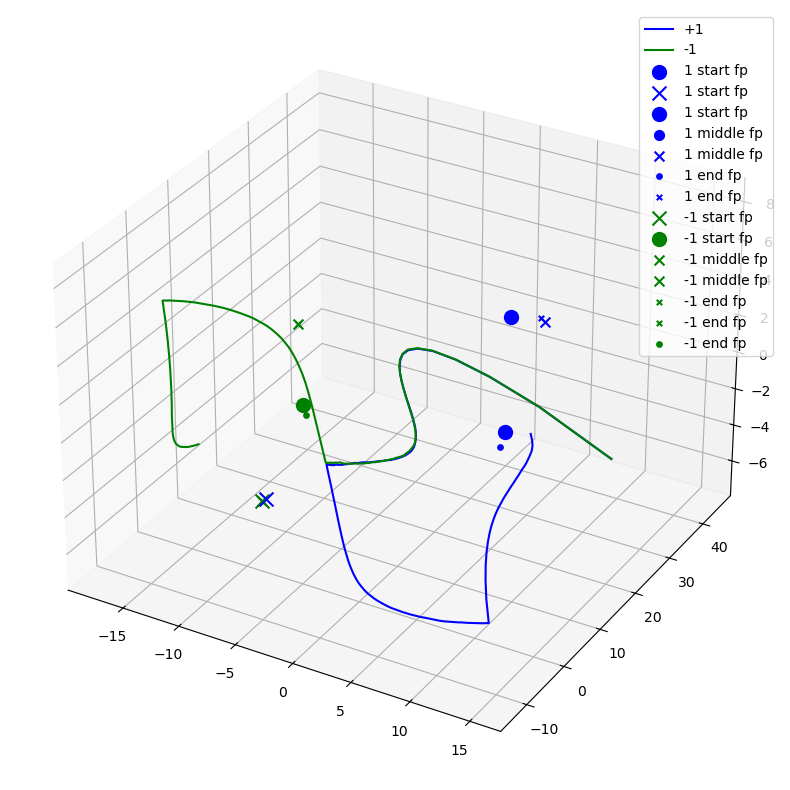

In [9]:
# plot 3d pca
# %matplotlib inline
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

# first plot mean of the trial types
ax.plot(xx_pca_pos_mean[:,0],xx_pca_pos_mean[:,1],xx_pca_pos_mean[:,2],'b', label='+1')
ax.plot(xx_pca_neg_mean[:,0],xx_pca_neg_mean[:,1],xx_pca_neg_mean[:,2],'g', label= '-1')

# plot random sample from each
# n_samples = 5
# pos_samp_idx = np.random.randint(xx_pca_pos.shape[0],size=n_samples)
# ax.plot(xx_pca_pos[pos_samp_idx,:,0].T,
#         xx_pca_pos[pos_samp_idx,:,1].T,
#         xx_pca_pos[pos_samp_idx,:,2].T,'b', alpha=0.3)
# neg_samp_idx = np.random.randint(xx_pca_neg.shape[0],size=n_samples)
# ax.plot(xx_pca_neg[neg_samp_idx,:,0].T,
#         xx_pca_neg[neg_samp_idx,:,1].T,
#         xx_pca_neg[neg_samp_idx,:,2].T,'g', alpha=0.3)

shapes = ['o','x']
label = ['stable','unstable']
colors = ['b','g']
# alphas = [1, 0.75, 0.5]
sizes = [100, 50, 15]

fixed_pt_count = 0
for i, task_type in enumerate(task_types): # +1 or -1
    color = colors[i]

    for j, time_fp_label in enumerate(time_fp_labels): # start, middle, end
        # alpha = alphas[j]
        fp_dict = fixed_pt_results[(task_type, time_fp_label)]
        n_fp = len(fp_dict['xstar'])
        fp_pca = fixedpt_pca[fixed_pt_count:fixed_pt_count+n_fp,:]
        fixed_pt_count += n_fp
        is_stability = fp_dict['is_stable']

        print(f'{task_type} {time_fp_label} fp count: {n_fp}')

        if n_fp > 0:
            for k in range(n_fp):
                # if j == 0: # only label once
                #      ax.scatter(fp_pca[k,0],fp_pca[k,1],fp_pca[k,2],
                #                 color=color,marker=shapes[is_stability[k]], 
                #                 label=f'{task_type} fp', alpha=alphas[j])
                # else:
                #      ax.scatter(fp_pca[k,0],fp_pca[k,1],fp_pca[k,2],
                #                 color=color,marker=shapes[is_stability[k]], 
                #                 alpha=alphas[j])
                     
                ax.scatter(fp_pca[k,0],fp_pca[k,1],fp_pca[k,2],
                        color=color,marker=shapes[is_stability[k]], 
                        label=f'{task_type} {time_fp_label} fp', s=sizes[j])
    
plt.legend()
plt.show()

1 start fp count: 3
1 middle fp count: 2
1 end fp count: 2
-1 start fp count: 2
-1 middle fp count: 2
-1 end fp count: 3


/tmp/ipykernel_556518/711908236.py:56: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  color=color,marker=shapes[is_stability[k]],


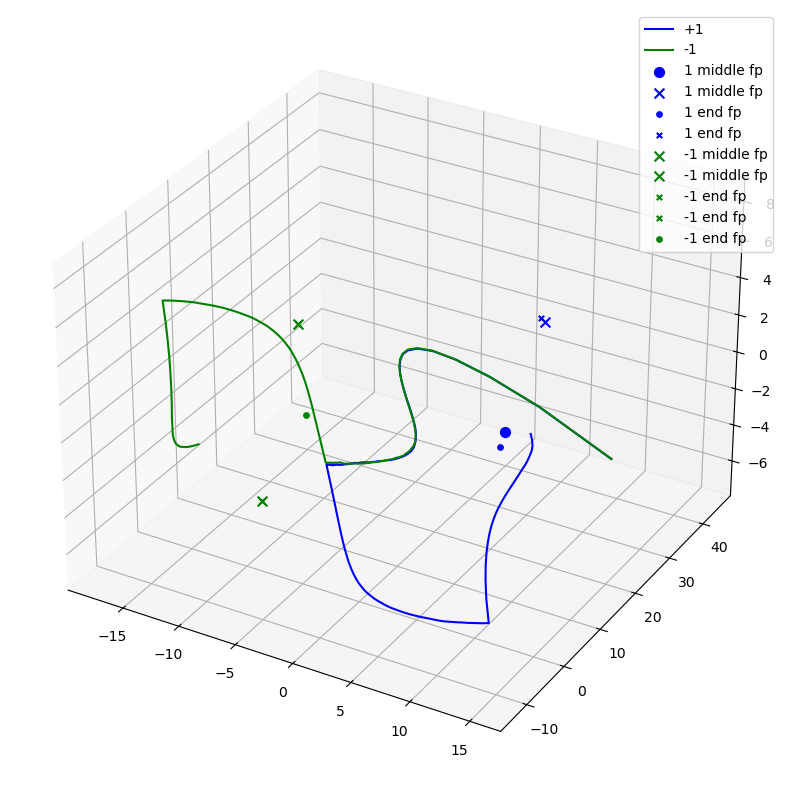

In [ ]:
# plot 3d pca; without the largest point (for visualization purposes)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

# first plot mean of the trial types
ax.plot(xx_pca_pos_mean[:,0],xx_pca_pos_mean[:,1],xx_pca_pos_mean[:,2],'b', label='+1')
ax.plot(xx_pca_neg_mean[:,0],xx_pca_neg_mean[:,1],xx_pca_neg_mean[:,2],'g', label= '-1')


shapes = ['o','x']
label = ['stable','unstable']
colors = ['b','g']
# alphas = [1, 0.75, 0.5]
sizes = [100, 50, 15]

fixed_pt_count = 0
for i, task_type in enumerate(task_types): # +1 or -1
    color = colors[i]

    for j, time_fp_label in enumerate(time_fp_labels): # start, middle, end
        # alpha = alphas[j]
        
        fp_dict = fixed_pt_results[(task_type, time_fp_label)]
        n_fp = len(fp_dict['xstar'])
        fp_pca = fixedpt_pca[fixed_pt_count:fixed_pt_count+n_fp,:]
        fixed_pt_count += n_fp
        is_stability = fp_dict['is_stable']

        print(f'{task_type} {time_fp_label} fp count: {n_fp}')
        if j == 0:
            continue

        if n_fp > 0:
            for k in range(n_fp):
                # if j == 0: # only label once
                #      ax.scatter(fp_pca[k,0],fp_pca[k,1],fp_pca[k,2],
                #                 color=color,marker=shapes[is_stability[k]], 
                #                 label=f'{task_type} fp', alpha=alphas[j])
                # else:
                #      ax.scatter(fp_pca[k,0],fp_pca[k,1],fp_pca[k,2],
                #                 color=color,marker=shapes[is_stability[k]], 
                #                 alpha=alphas[j])
                     
                ax.scatter(fp_pca[k,0],fp_pca[k,1],fp_pca[k,2],
                        color=color,marker=shapes[is_stability[k]], 
                        label=f'{task_type} {time_fp_label} fp', s=sizes[j])
    
plt.legend()
plt.show()

0 3
1 start fp count: 3
(3, 3)
3 5
1 middle fp count: 2
(2, 3)
5 7
1 end fp count: 2
(2, 3)
7 9
-1 start fp count: 2
(2, 3)
9 11
-1 middle fp count: 2
(2, 3)
11 14
-1 end fp count: 3
(3, 3)


/tmp/ipykernel_555865/3484537201.py:52: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  color=color,marker=shapes[is_stability[k]],


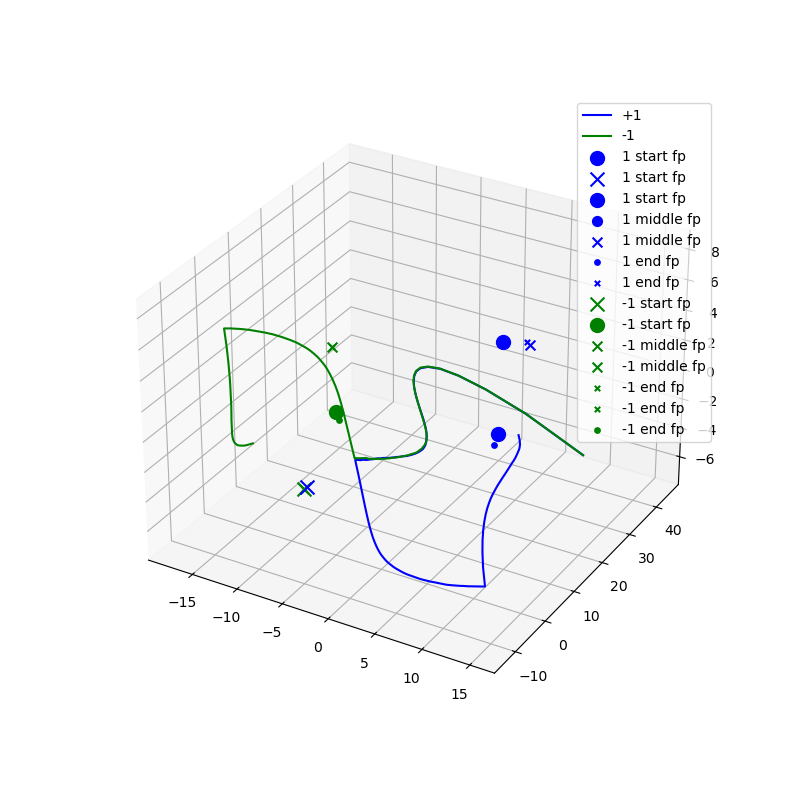

In [18]:
# plot 3d pca

# change matplotlib style so can rotate in 3d
%matplotlib ipympl

fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(111, projection='3d')

# first plot mean of the trial types
ax.plot(xx_pca_pos_mean[:,0],xx_pca_pos_mean[:,1],xx_pca_pos_mean[:,2],'b', label='+1')
ax.plot(xx_pca_neg_mean[:,0],xx_pca_neg_mean[:,1],xx_pca_neg_mean[:,2],'g', label= '-1')

# plot random sample from each
# n_samples = 5
# pos_samp_idx = np.random.randint(xx_pca_pos.shape[0],size=n_samples)
# ax.plot(xx_pca_pos[pos_samp_idx,:,0].T,
#         xx_pca_pos[pos_samp_idx,:,1].T,
#         xx_pca_pos[pos_samp_idx,:,2].T,'b', alpha=0.3)
# neg_samp_idx = np.random.randint(xx_pca_neg.shape[0],size=n_samples)
# ax.plot(xx_pca_neg[neg_samp_idx,:,0].T,
#         xx_pca_neg[neg_samp_idx,:,1].T,
#         xx_pca_neg[neg_samp_idx,:,2].T,'g', alpha=0.3)

shapes = ['o','x']
label = ['stable','unstable']
colors = ['b','g']
# alphas = [1, 0.75, 0.5]
sizes = [100, 50, 15]

fixed_pt_count = 0
for i, task_type in enumerate(task_types): # +1 or -1
    color = colors[i]

    for j, time_fp_label in enumerate(time_fp_labels): # start, middle, end
        # alpha = alphas[j]
        fp_dict = fixed_pt_results[(task_type, time_fp_label)]
        n_fp = len(fp_dict['xstar'])

        print(fixed_pt_count, fixed_pt_count + n_fp)
        fp_pca = fixedpt_pca[fixed_pt_count:fixed_pt_count+n_fp,:]
        fixed_pt_count += n_fp
        is_stability = fp_dict['is_stable']

        print(f'{task_type} {time_fp_label} fp count: {n_fp}')
        print(fp_pca.shape)


        if n_fp > 0:
            for k in range(n_fp):
                     
                ax.scatter(fp_pca[k,0],fp_pca[k,1],fp_pca[k,2],
                        color=color,marker=shapes[is_stability[k]], 
                        label=f'{task_type} {time_fp_label} fp', s=sizes[j])
    
plt.legend()
plt.show()

## Bad model

In [2]:
models_type = 'bad_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [3]:
RNN_model_file = model_list[0] # just grab the first model
model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'

print(f'Loading model: {RNN_model_file}')
rnn_path = os.path.join(models_dir, RNN_model_file) 
model = lrm.load_RNN_model(rnn_path)

settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 50, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

if not os.path.exists(f'{model_results_dir}delay{settings["delay"]}_synX.npy'):
        print('Generating synX')
        xx_trials, trial_stim_labels = tu.generate_synX(rnn_path, settings, 
                                save=1, model_results_dir = model_results_dir)
else:
        print('Loading synX')
        xx_trials = np.load(f'{model_results_dir}delay{settings["delay"]}_synX.npy')
        trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels.npy')

stim_on = settings['stim_on']
stim_dur = settings['stim_dur']
delay=settings['delay']
T = settings['T']

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152906.mat
Loading synX


In [4]:
# get fixed points

importlib.reload(tu)

if os.path.exists(f'{model_results_dir}fixed_pt_results.pkl'):
    print('loading fixed point optimization results')
    fixed_pt_results = pk.load(open(f'{model_results_dir}fixed_pt_results.pkl', 'rb'))
else:
    print('Running fixed point optimization')

    _ = tu.calculate_fixed_pts(RNN_model_file = RNN_model_file, xx_trials = xx_trials,
                                            trial_stim_labels = trial_stim_labels, settings = settings,
                                            save=1, models_dir = models_dir)
    fixed_pt_results = pk.load(open(f'{model_results_dir}fixed_pt_results.pkl', 'rb'))

loading fixed point optimization results


#### now PCA

1 start fp count: 1, stability: [ True]
1 middle fp count: 3, stability: [ True False  True]
1 end fp count: 2, stability: [ True False]
-1 start fp count: 1, stability: [ True]
-1 middle fp count: 1, stability: [ True]
-1 end fp count: 1, stability: [False]


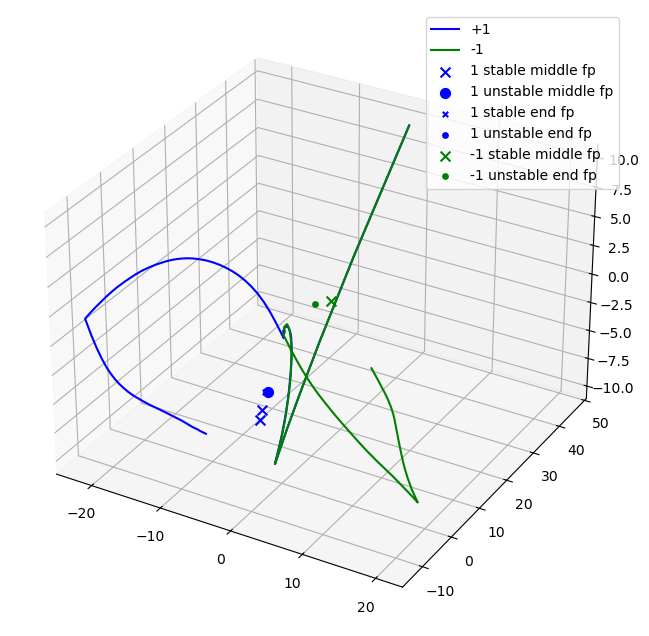

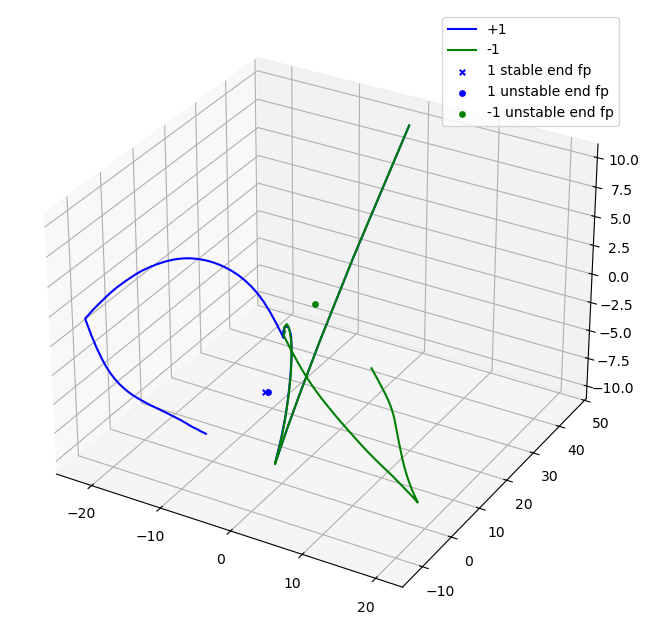

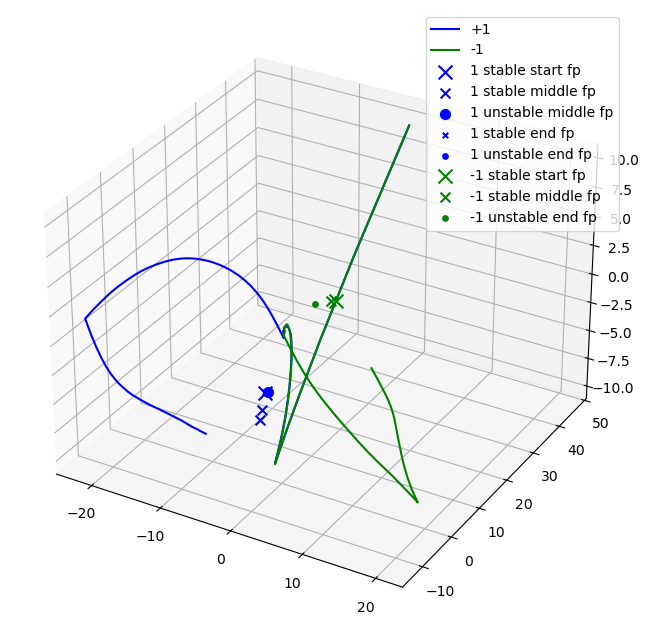

In [7]:
%matplotlib inline
importlib.reload(tu)
tu.plot_fixed_pts(fixed_pt_results, model_results_dir, settings,
                   xx_trials, trial_stim_labels, plot_examples=0)

1 middle fp count: 3, stability: [ True False  True]
1 end fp count: 2, stability: [ True False]
-1 middle fp count: 1, stability: [ True]
-1 end fp count: 1, stability: [False]


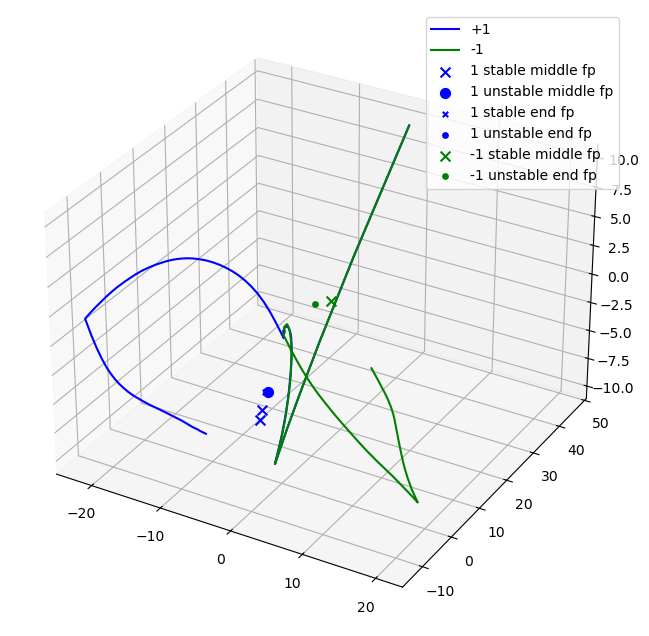

In [8]:
%matplotlib inline
importlib.reload(tu)
tu.plot_fixed_pts(fixed_pt_results, model_results_dir, settings,
                   xx_trials, trial_stim_labels, plot_examples=0,
                   skip_start=1)

1 end fp count: 2, stability: [ True False]
-1 end fp count: 1, stability: [False]


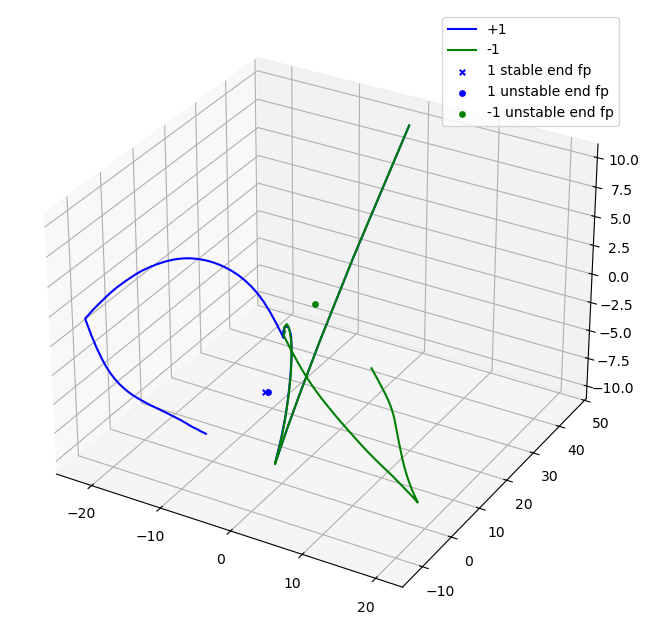

In [9]:
%matplotlib inline
importlib.reload(tu)
tu.plot_fixed_pts(fixed_pt_results, model_results_dir, settings,
                   xx_trials, trial_stim_labels, plot_examples=0, 
                   skip_start=1, skip_mid=1)

1 start fp count: 1, stability: [ True]
1 middle fp count: 3, stability: [ True False  True]
1 end fp count: 2, stability: [ True False]
-1 start fp count: 1, stability: [ True]
-1 middle fp count: 1, stability: [ True]
-1 end fp count: 1, stability: [False]


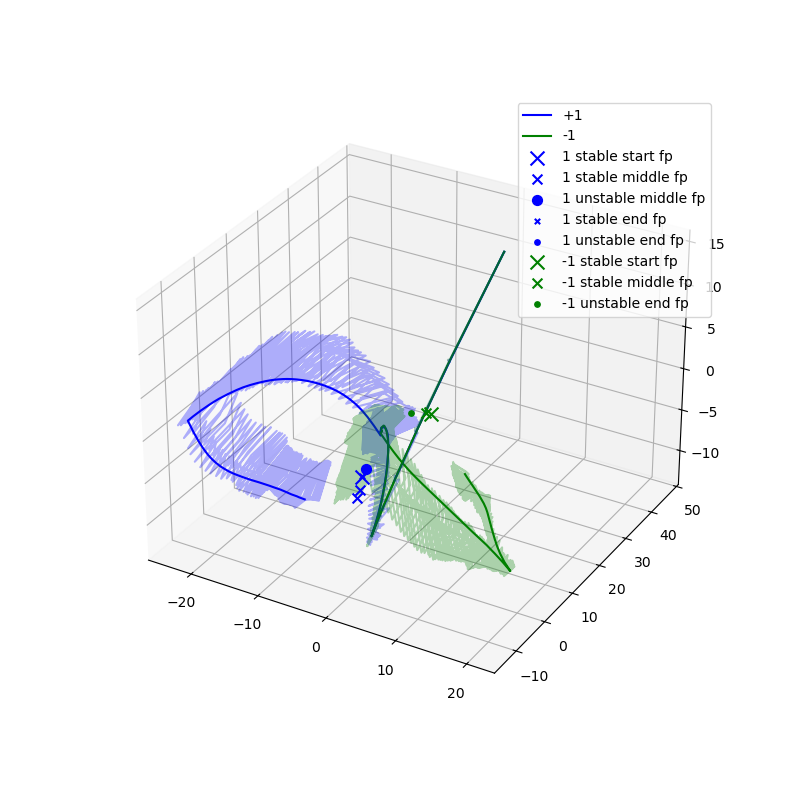

In [32]:
%matplotlib ipympl
importlib.reload(tu)
tu.plot_fixed_pts(fixed_pt_results, model_results_dir, settings,
                   xx_trials, trial_stim_labels, plot_examples=1)

## Good model (now using condensed code)

In [2]:
models_type = 'good_models'

models_dir = '/scratch/spikeRNN/models/DMS_OSF/' # dir where all models are located
results_dir = f'{models_dir}{models_type}/' # dir where results are saved

model_list_path = f'{results_dir}{models_type}_list.mat' # list (saved from matlab) of models of interest
model_list_cell = scipy.io.loadmat(model_list_path)['stable_mods'][0] 
model_list = [model_list_cell[i][0] for i in range(len(model_list_cell))]

In [3]:
RNN_model_file = model_list[0] # just grab the first model
model_results_dir = f'{models_dir}{RNN_model_file[:-4]}/'

print(f'Loading model: {RNN_model_file}')
rnn_path = os.path.join(models_dir, RNN_model_file) 
model = lrm.load_RNN_model(rnn_path)

settings = {
        'T': 500, # trial duration (in steps)
        'stim_on': 200, # input stim onset (in steps)
        'stim_dur': 50, # input stim duration (in steps)
        'delay': 50, # delay b/w the two stimuli (in steps)
        'DeltaT': 1, # sampling rate
        'taus': 20, # decay time-constants (in steps)
        'task': 'xor', # task name
        }

if not os.path.exists(f'{model_results_dir}delay{settings["delay"]}_synX.npy'):
        print('Generating synX')
        xx_trials, trial_stim_labels = tu.generate_synX(rnn_path, settings, 
                                save=1, model_results_dir = model_results_dir)
else:
        print('Loading synX')
        xx_trials = np.load(f'{model_results_dir}delay{settings["delay"]}_synX.npy')
        trial_stim_labels = np.load(f'{model_results_dir}trial_stim_labels.npy')

stim_on = settings['stim_on']
stim_dur = settings['stim_dur']
delay=settings['delay']
T = settings['T']

Loading model: Task_xor_N_200_Taus_4.0_25.0_Act_sigmoid_2019_09_06_152659.mat
Loading synX


In [4]:
# get fixed points

importlib.reload(tu)

if os.path.exists(f'{model_results_dir}fixed_pt_results.pkl'):
    print('loading fixed point optimization results')
    fixed_pt_results = pk.load(open(f'{model_results_dir}fixed_pt_results.pkl', 'rb'))
else:
    print('Running fixed point optimization')

    _ = tu.calculate_fixed_pts(RNN_model_file = RNN_model_file, xx_trials = xx_trials,
                                            trial_stim_labels = trial_stim_labels, settings = settings,
                                            save=1, models_dir = models_dir)
    fixed_pt_results = pk.load(open(f'{model_results_dir}fixed_pt_results.pkl', 'rb'))

loading fixed point optimization results


#### now PCA

1 start fp count: 3, stability: [False  True False]
1 middle fp count: 2, stability: [False  True]
1 end fp count: 2, stability: [False  True]
-1 start fp count: 2, stability: [ True False]
-1 middle fp count: 2, stability: [ True  True]
-1 end fp count: 3, stability: [ True  True False]


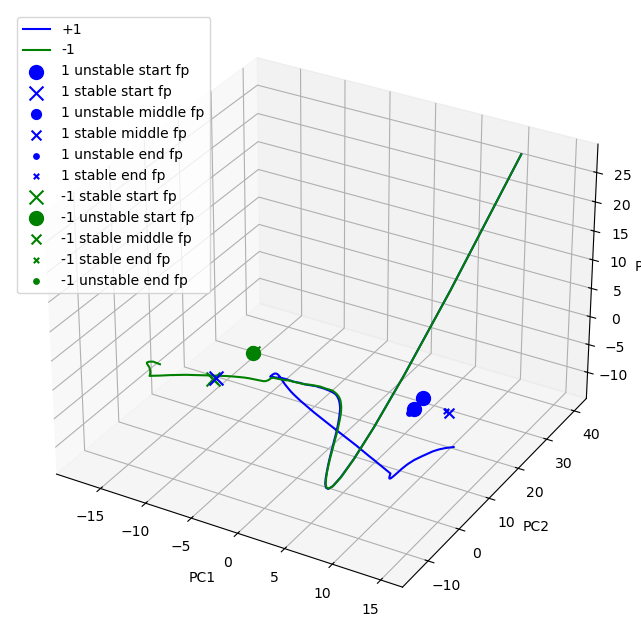

In [5]:
# %matplotlib ipympl
importlib.reload(tu)
tu.plot_fixed_pts(fixed_pt_results, model_results_dir, settings,
                   xx_trials, trial_stim_labels, plot_examples=0)

1 middle fp count: 2, stability: [False  True]
1 end fp count: 2, stability: [False  True]
-1 middle fp count: 2, stability: [ True  True]
-1 end fp count: 3, stability: [ True  True False]


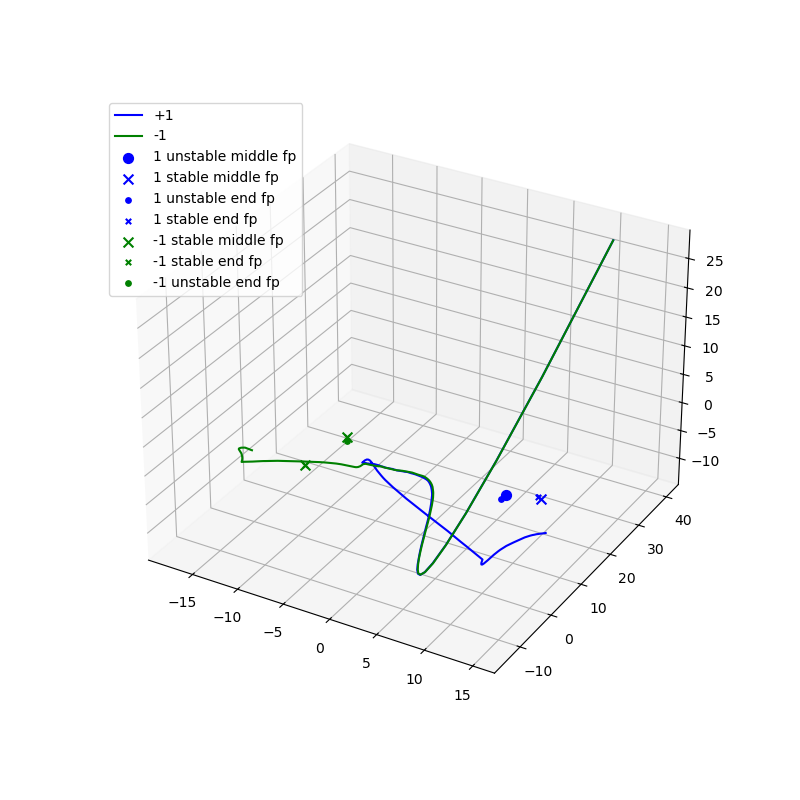

In [10]:
%matplotlib ipympl
importlib.reload(tu)
tu.plot_fixed_pts(fixed_pt_results, model_results_dir, settings,
                   xx_trials, trial_stim_labels, plot_examples=0)

1 end fp count: 2, stability: [False  True]
-1 end fp count: 3, stability: [ True  True False]


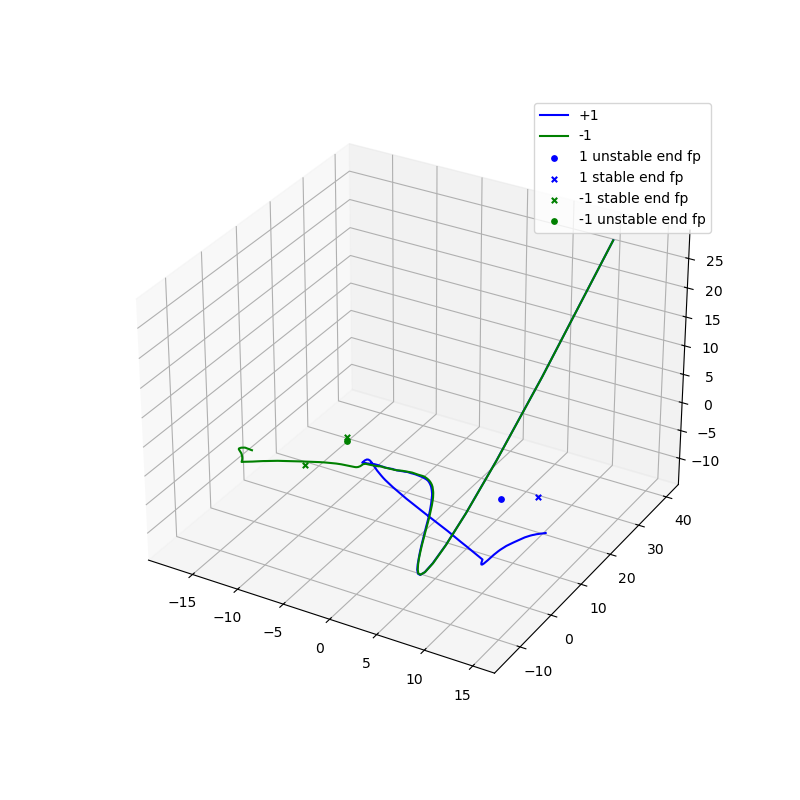

In [11]:
%matplotlib ipympl
importlib.reload(tu)
tu.plot_fixed_pts(fixed_pt_results, model_results_dir, settings,
                   xx_trials, trial_stim_labels, plot_examples=0)

1 start fp count: 3, stability: [False  True False]
1 middle fp count: 2, stability: [False  True]
1 end fp count: 2, stability: [False  True]
-1 start fp count: 2, stability: [ True False]
-1 middle fp count: 2, stability: [ True  True]
-1 end fp count: 3, stability: [ True  True False]


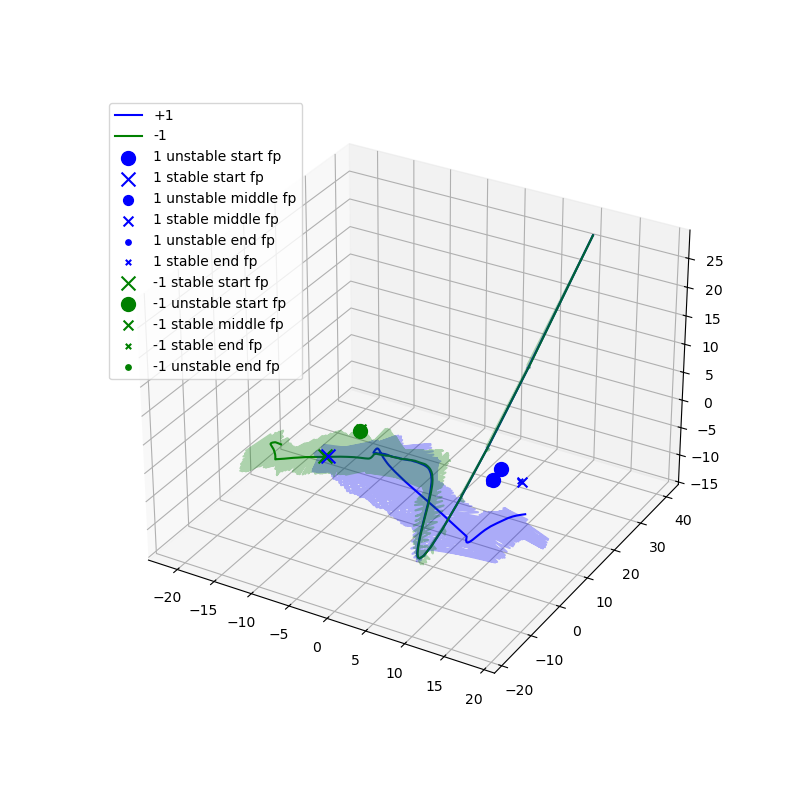

In [9]:
%matplotlib ipympl
importlib.reload(tu)
tu.plot_fixed_pts(fixed_pt_results, model_results_dir, settings,
                   xx_trials, trial_stim_labels, plot_examples=1)

#### now PCA

In [5]:
task_types = [1, -1] # for the first stimulus
time_fp_labels = ['start','middle','end'] # relative to the delay period

In [ ]:
# transform the trial data (minus fixed points)

xx_trials_thrudelay = xx_trials[:,:stim_on+stim_dur+delay,:] # nTrials x nTimes x nNeurons

n_neurons = xx_trials_thrudelay.shape[2]
n_times = xx_trials_thrudelay.shape[1]

xx_trials_thrudelay = xx_trials_thrudelay.reshape(-1,n_neurons) # time x neurons

pca_delay = PCA(n_components=3)
pca_delay.fit(xx_trials_thrudelay)
xx_pca = pca_delay.transform(xx_trials_thrudelay)
xx_pca = xx_pca.reshape(-1,n_times,3)
print(xx_pca.shape)

(1000, 300, 3)


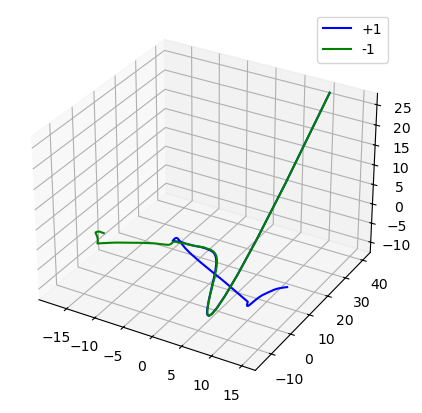

In [15]:
# plot 3d pca
xx_pca_pos_mean = np.mean(xx_pca[trial_stim_labels[:,0] == 1],axis=0)
xx_pca_neg_mean = np.mean(xx_pca[trial_stim_labels[:,0] == -1],axis=0)

fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='3d')

# first plot mean of the trial types
ax.plot(xx_pca_pos_mean[:,0],xx_pca_pos_mean[:,1],xx_pca_pos_mean[:,2],'b', label='+1')
ax.plot(xx_pca_neg_mean[:,0],xx_pca_neg_mean[:,1],xx_pca_neg_mean[:,2],'g', label= '-1')
    
plt.legend()
plt.show()

In [19]:
fixed_pt_pca = pca_delay.transform(fp_dict['xstar'])
fixed_pt_pca.shape

(3, 3)

/tmp/ipykernel_697069/3150293909.py:26: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  color=color, marker=shapes[is_stability[i_fp]], s=sizes[j],
/tmp/ipykernel_697069/3150293909.py:27: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  label=f'{task_type} {label[is_stability[i_fp]]} {time_fp_label}')
/tmp/ipykernel_697069/3150293909.py:26: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  color=color, marker=shapes[is_stability[i_fp]], s=sizes[j],
/tmp/ipykernel_697069/3150293909.py:27: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  label=f'{task_type} {label[is_stability[i_fp]]} {time_fp_label}')
/tmp/ipykernel_697069/3150293909.py:26: DeprecationWarning: In future, it will be an error for 'np.bool_' scalars to be interpreted as an index
  color=color, marke

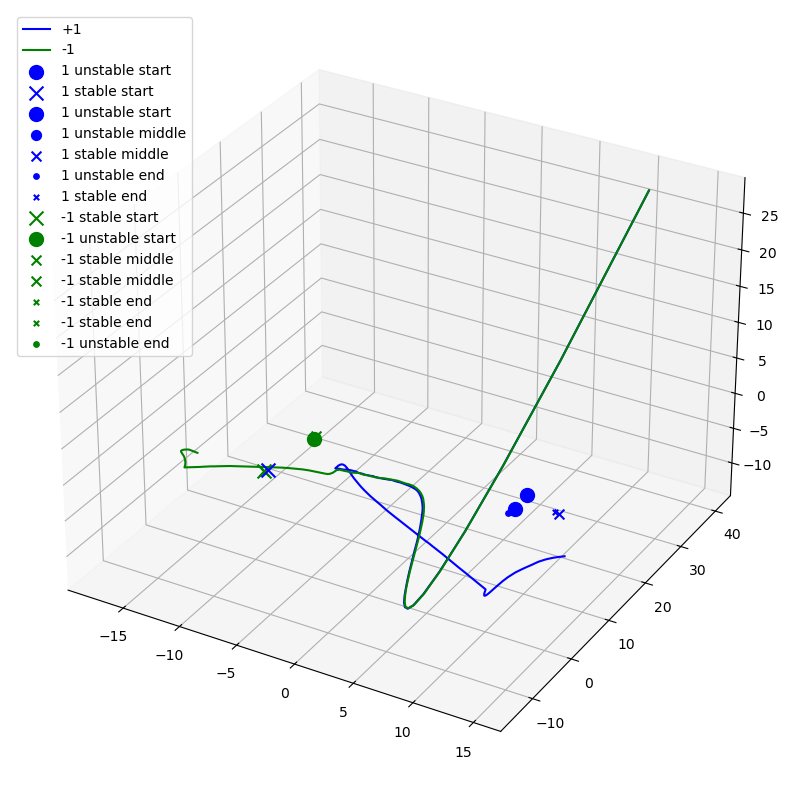

In [28]:
# plot 3d pca
shapes = ['o','x']
label = ['unstable','stable']
colors = ['b','g']
sizes = [100, 50, 15]

xx_pca_pos_mean = np.mean(xx_pca[trial_stim_labels[:,0] == 1],axis=0)
xx_pca_neg_mean = np.mean(xx_pca[trial_stim_labels[:,0] == -1],axis=0)

fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

# first plot mean of the trial types
ax.plot(xx_pca_pos_mean[:,0],xx_pca_pos_mean[:,1],xx_pca_pos_mean[:,2],'b', label='+1')
ax.plot(xx_pca_neg_mean[:,0],xx_pca_neg_mean[:,1],xx_pca_neg_mean[:,2],'g', label= '-1')

# now add in fixed points
for i, task_type in enumerate(task_types):
    color = colors[i]
    for j, time_fp_label in enumerate(time_fp_labels):
        fp_dict = fixed_pt_results[(task_type, time_fp_label)]
        is_stability = fp_dict['is_stable']
        fixed_pt_pca = pca_delay.transform(fp_dict['xstar'])
        for i_fp, fp in enumerate(fixed_pt_pca):
            ax.scatter(fp[0],fp[1],fp[2],
                       color=color, marker=shapes[is_stability[i_fp]], s=sizes[j],
                       label=f'{task_type} {label[is_stability[i_fp]]} {time_fp_label}')
    

plt.legend()
plt.show()

(1000, 300, 3)
1 start fp count: 3, stability: [False  True False]
1 middle fp count: 2, stability: [False  True]
1 end fp count: 2, stability: [False  True]
-1 start fp count: 2, stability: [ True False]
-1 middle fp count: 2, stability: [ True  True]
-1 end fp count: 3, stability: [ True  True False]


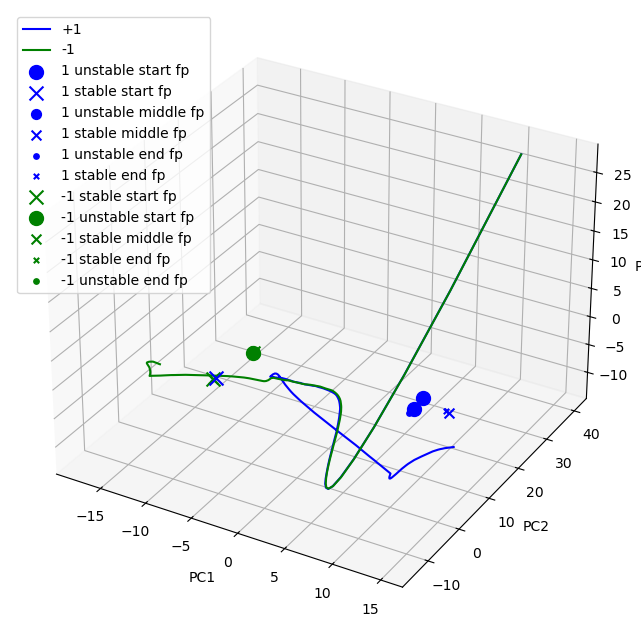

In [30]:
# %matplotlib ipympl
importlib.reload(tu)
tu.plot_fixed_pts(fixed_pt_results, model_results_dir, settings,
                   xx_trials, trial_stim_labels, plot_examples=0)